In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE


___

<p style="color:red;font-size:80px"> Understand credit_record data

In [3]:
credit_record=pd.read_csv('data/credit_record.csv')

In [ ]:
credit_record.columns

In [ ]:
credit_record.shape

In [ ]:
credit_record['STATUS'].unique()

X = No loan / No credit yet

0 = Paid on time

1 = 1 month delay

2 = 2 months delay

3 = 3 months delay

4 = 4 months delay

5 = 5+ months delay

C = Account closed

MONTHS_BALANCE=>Number of months before the last registration date in the system

___

<p style="color:red;font-size:80px">understand application_record data

In [ ]:
application_record=pd.read_csv('data/application_record.csv')

In [ ]:
application_record.columns

In [ ]:
application_record.shape

  [1]'ID'-->primary key to connect with credit record

,[2]'CODE_GENDER'-->male or female

,[3]'FLAG_OWN_CAR' -->Indicates whether the applicant owns a car (Y = Yes, N = No)

,[4]'FLAG_OWN_REALTY'-->Indicates if the applicant owns real estate property (e.g., house or apartment)

, [5]'CNT_CHILDREN'-->Number of children the applicant is responsible for

, [6]'AMT_INCOME_TOTAL' -->Total annual income of the applicant (numeric, financial indicator)

, [7]'NAME_INCOME_TYPE' -->Type/source of income (e.g., Working, Pensioner, Student, Unemployed)

,[8]'NAME_EDUCATION_TYPE'-->Applicant’s highest completed education level.

, [9]'NAME_FAMILY_STATUS'-->Applicant’s marital/family status (e.g., Married, Single, Civil marriage).

,[10]'NAME_HOUSING_TYPE'-->Applicant’s housing type (e.g., Owned, Rented, House/apartment).

,[11]'DAYS_BIRTH'-->Age of applicant in days (negative value; convert to age by -DAYS_BIRTH/365).

, [12]'DAYS_EMPLOYED'-->Length of employment in days (negative values; large positive values often indicate unemployment or missing information)

, [13]'FLAG_MOBIL'-->Indicates if the applicant has a mobile phone (binary).

,[14]'FLAG_WORK_PHONE'-->Indicates if the applicant has a work phone number (binary).

,[15]'FLAG_PHONE'-->Indicates the presence of a personal phone number (binary).

,[16]'FLAG_EMAIL'-->Indicates if the applicant provided an email address (binary).

,[17]'OCCUPATION_TYPE'-->Applicant’s occupation category (e.g., Sales staff, Managers, Accountants).

,[18]'CNT_FAM_MEMBERS'-->Total number of family members living with the applicant.

_____

<p style="color:red;font-size:80px">preprocessing to credit_record

## [1]chk Values

In [ ]:
for col in credit_record.columns:
    print(col,' --> ',credit_record[col].unique())

___

## [2]chk data_type to cols

In [ ]:
for col in credit_record.columns:
    print(col,' --> ',credit_record[col].dtype)

## note--> in status not exist excess spaces to the right and left of the word

____

## [3]chk missing values

In [ ]:
credit_record.isna().sum()

## no missing value in credit_record data

___

## [4]chk duplicates

In [ ]:
duplicate_count = credit_record.duplicated().sum()
total_rows = len(credit_record)
duplication_rate = (duplicate_count / total_rows) * 100

print(f"duplicate_count: {duplicate_count}")
print(f"duplication_rate: {duplication_rate:.2f}%")

## no duplicates

___

## [5]Encding to  Status

0,1,2,3,4,5  --> category with ordianl

x,c -->category wihout ordianl

In [ ]:
status_map = {'X': -1, 'C': 0, '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}
credit_record['STATUS_NUM'] = credit_record['STATUS'].map(status_map)

In [ ]:
credit_record.head(50)

___

## [6]feature engineering and grouped by id

In [ ]:
credit_record = credit_record.sort_values(['ID','MONTHS_BALANCE'], ascending=[True, False])

# Aggregate + trend features 
def get_trend(x):
    return x.diff().mean()  #Average change between months

agg_funcs = {
    'STATUS_NUM':['max','min','mean','last', get_trend] #It will be collected according to STATUS_NUM
}

features_credit_record = credit_record.groupby('ID').agg(agg_funcs) 
features_credit_record.columns = ['STATUS_MAX','STATUS_MIN','STATUS_MEAN','STATUS_LAST','STATUS_TREND']
features_credit_record.reset_index(inplace=True)

# NUM_LATE_MONTHS
features_credit_record['NUM_LATE_MONTHS'] = credit_record.groupby('ID')['STATUS_NUM'].apply(lambda x: (x>0).sum()).values

print(features_credit_record.head(50))

In [ ]:
features_credit_record.shape

___

## [7]chk outliers

In [ ]:
for col in features_credit_record.columns:
    Q1 = features_credit_record[col].quantile(0.25)
    Q3 = features_credit_record[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = features_credit_record[(features_credit_record[col] < lower_bound) | (features_credit_record[col] > upper_bound)]
    print(f"number of outliers in {col} :  {len(outliers)}")

Outliers Analysis – Credit Record Features

Overview:

Outliers are values that are significantly different from the rest of the data. In credit record features, not all outliers 

are errors—some represent true extreme cases, which are important for modeling credit risk.



[Feature-wise Notes:]

-->STATUS_MAX / NUM_LATE_MONTHS:

High values indicate customers with severe delays or many late months.

These are real signals for credit risk and should be retained.



-->STATUS_MEAN / STATUS_TREND:

Some extreme values may appear due to unusual sequences or missing data (e.g., 'X' → unknown).

It is reasonable to apply clipping to reduce the effect of extreme slopes while keeping meaningful patterns.



--->STATUS_LAST / STATUS_MIN:

Usually safe; few or no problematic outliers.


___

## chk NaN

In [ ]:
features_credit_record.isna().sum()

In [ ]:
features_credit_record['STATUS_TREND'] = features_credit_record['STATUS_TREND'].fillna(0)

## when exist one month only trend =0 

In [ ]:
features_credit_record.isna().sum()

____

## overview on finished data 

In [ ]:
features_credit_record.head(50)

In [ ]:
features_credit_record.shape

## in first

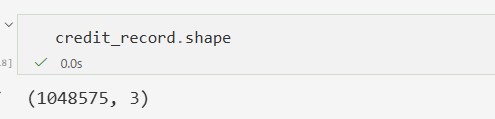

In [ ]:
for col in features_credit_record.columns:
    print(col,' --> ',features_credit_record[col].dtype)

In [ ]:
for col in features_credit_record.columns:
    print(col,' --> ',features_credit_record[col].unique())

____

<p style="color:red;font-size:80px">preprocesssing to application_record

## [1]chk data type

In [ ]:
for col in application_record.columns:
    print(col,' --> ',application_record[col].dtype)

In [ ]:
for col in application_record.columns:
    if(application_record[col].dtype==object):
     print(col,' --> ',application_record[col].dtype)

____

In [ ]:
application_record.shape

## [2]chk Values

In [ ]:
for col in application_record.columns:
 print(col,' --> ',application_record[col].unique())

In [ ]:
for col in application_record.columns:
    if(application_record[col].dtype==object):
     print(col,' --> ',application_record[col].unique())

___

## [3]Feature engineering 

In [ ]:
application_record['AGE'] = (-application_record['DAYS_BIRTH'] / 365).astype(int)


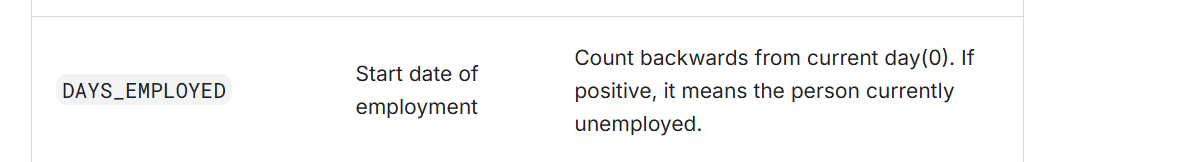

In [1]:
application_record['EMPLOYED'] = application_record['DAYS_EMPLOYED'] != 365243
application_record['YEARS_EMPLOYED'] = application_record['DAYS_EMPLOYED'].apply(lambda x: max(-x / 365, 0) if x != 365243 else 0)

NameError: name 'application_record' is not defined

remove DAYS_BIRTH ,DAYS_EMPOLYED

In [ ]:
application_record.drop(['DAYS_EMPLOYED','DAYS_BIRTH'],axis=1,inplace=True)

In [ ]:
application_record['INCOME_PER_PERSON'] = (
    application_record['AMT_INCOME_TOTAL'] / 
    application_record['CNT_FAM_MEMBERS']
)

In [ ]:
application_record['INCOME_AGE_RATIO'] = application_record['AMT_INCOME_TOTAL'] / application_record['AGE']

In [ ]:
application_record['INCOME_EMPLOY_RATIO'] = application_record.apply(
    lambda row: row['AMT_INCOME_TOTAL'] / row['YEARS_EMPLOYED'] if row['YEARS_EMPLOYED'] > 0 else row['AMT_INCOME_TOTAL'], axis=1
)


In [ ]:
application_record['CHILD_RATIO'] = application_record['CNT_CHILDREN'] / application_record['CNT_FAM_MEMBERS']

____________

## [4]chk missing values

In [2]:
application_record.isna().sum()

NameError: name 'application_record' is not defined

In [ ]:
application_record.isna().mean() * 100

 Pensioners 

 Unemployed 

 Housewives / Househusbands

 Students

In [ ]:
application_record['OCCUPATION_TYPE'] = application_record['OCCUPATION_TYPE'].fillna('Unknown')

In [ ]:
application_record.isna().mean() * 100

____

## [5]chk duplicates

In [ ]:
duplicate_count = application_record.duplicated().sum()
total_rows = len(application_record)
duplication_rate = (duplicate_count / total_rows) * 100

print(f"duplicate_count: {duplicate_count}")
print(f"duplication_rate: {duplication_rate:.2f}%")

## no dublicates

___

## [6]Encoding

[1]Binary
---------------------------------------------
FLAG_OWN_CAR  -->  ['Y' 'N']

FLAG_OWN_REALTY  -->  ['Y' 'N']




[2]category without ordinal
-------------------------------------------------
CODE_GENDER  -->  ['M' 'F']


NAME_INCOME_TYPE  -->  ['Working' 'Commercial associate' 'Pensioner' 'State servant' 'Student']

NAME_FAMILY_STATUS  -->  ['Civil marriage' 'Married' 'Single / not married' 'Separated' 'Widow']

NAME_HOUSING_TYPE  -->  ['Rented apartment' 'House / apartment' 'Municipal apartment'
 'With parents' 'Co-op apartment' 'Office apartment']

OCCUPATION_TYPE  -->  [nan 'Security staff' 'Sales staff' 'Accountants' 'Laborers' 'Managers'
 'Drivers' 'Core staff' 'High skill tech staff' 'Cleaning staff'
 'Private service staff' 'Cooking staff' 'Low-skill Laborers'
 'Medicine staff' 'Secretaries' 'Waiters/barmen staff' 'HR staff'
 'Realty agents' 'IT staff']


[3]category with ordinal
-------------------------------------------------
NAME_EDUCATION_TYPE  -->  ['Higher education' 'Secondary / secondary special' 'Incomplete higher'
 'Lower secondary' 'Academic degree']

In [ ]:
application_record.shape

In [ ]:
binary_features = [
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY'
]

nominal_features = [
    'CODE_GENDER',
    'NAME_INCOME_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]


ordinal_features = [
    'NAME_EDUCATION_TYPE'
]

In [ ]:
le=LabelEncoder()
for col in binary_features:
    application_record[col]=le.fit_transform(application_record[col])

In [ ]:
one = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_array = one.fit_transform(application_record[nominal_features])

one_df = pd.DataFrame(
    one_array,
    columns=one.get_feature_names_out(nominal_features),
    index=application_record.index
)

application_record = pd.concat(
    [application_record.drop(nominal_features, axis=1), one_df],
    axis=1
)


In [ ]:
ord=OrdinalEncoder()
application_record['NAME_EDUCATION_TYPE']=ord.fit_transform(application_record[['NAME_EDUCATION_TYPE']])

In [ ]:
application_record.shape

___

<p style="color:red;font-size:80px">Merge two DataFrame

In [ ]:
application_record.columns

In [ ]:
features_credit_record.columns

In [ ]:
df = application_record.merge(features_credit_record, on='ID', how='left')

In [ ]:
df['HAS_CREDIT_HISTORY'] = df['STATUS_MAX'].notna().astype(int) #return T/F and convert to 0,1 --> 1 if notna , 0 if na

credit_cols = ['STATUS_MAX','STATUS_MIN','STATUS_MEAN','STATUS_LAST','STATUS_TREND','NUM_LATE_MONTHS']
df[credit_cols] = df[credit_cols].fillna(0)#instead of NAN -->0 in rows not have credit card


In [ ]:
df['HAS_CREDIT_HISTORY'].unique()

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.head()

In [ ]:
df.isna().sum()

In [ ]:
duplicate_count = df.duplicated().sum()
total_rows = len(df)
duplication_rate = (duplicate_count / total_rows) * 100

print(f"duplicate_count: {duplicate_count}")
print(f"duplication_rate: {duplication_rate:.2f}%")

In [ ]:
for col in df.columns:
    print(col,' --> ',df[col].dtype)

<p style="color:red;font-size:80px">Create target

In [4]:
def make_target(row):
    if row['STATUS_LAST'] > 0 or row['STATUS_MAX'] > 0:
        return 0  # good client
    else:
        return 1  # bad client

df['TARGET'] = df.apply(make_target, axis=1)

print(df['TARGET'].value_counts())


NameError: name 'df' is not defined

In [3]:
df.head()

NameError: name 'df' is not defined

<p style="color:red;font-size:80px"> Visualization[Exploratory Data Analysis EDA]

<p style="color:green;font-size:80px">STATUS_MAX and STATUS_MIN cols

In [2]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(15, 8), sharex=False)

ax1.hist(df['STATUS_MAX'],color='r')
ax1.set_title('Maximum delay')
ax1.set_xlabel('period')
ax1.set_ylabel('Frequency')

ax2.hist(df['STATUS_MIN'],color='g')
ax2.set_title('Minmum delay')
ax2.set_xlabel('period')
ax2.set_ylabel('Frequency')

NameError: name 'plt' is not defined

X = No loan / No credit yet

C = Account closed

0 = Paid on time

1 = 1 month delay

2 = 2 months delay

3 = 3 months delay

4 = 4 months delay

5 = 5+ months delay

'X': -1, 

'C': 0, 

'0': 0, 

'1': 1, 

'2': 2, 

'3': 3, 

'4': 4, 

'5': 5

For each id it's maximum status [at most] 0 --> account closed or paid on time and [at least] 1 --> one month delay and -1 --> no credit card and in a [very small] percentage 2,5

for each id it's mininmum status [at most] 0 --> account closed or paid on time But here it tends towards one more and [at least] -1 --> no credit card

In [ ]:
sns.boxplot(x='TARGET', y='STATUS_MAX', data=df)
plt.title(f'Boxplot of STATUS_MAX vs TARGET')
plt.xlabel('TARGET')
plt.ylabel('STATUS_MAX')
plt.tight_layout()
plt.show()

target is 1  approval if status max it's mean 0  --> closed , paid on tome

target is 0 not approval if status max it's mean 1 -->one month delayed and 2,3,4,5 monthts delayed

In [ ]:
sns.boxplot(x='TARGET', y='STATUS_MIN', data=df)
plt.title(f'Boxplot of STATUS_MIN vs TARGET')
plt.xlabel('TARGET')
plt.ylabel('STATUS_MIN')
plt.tight_layout()
plt.show()

target is 1  approval if status min it's mean 0  --> closed , paid on tome

target is 0 not approval if status min [at most] 0 --> closed , paid on tome and -1  no credt card , [at least] 1 -->one month delayed

___

<p style="color:green;font-size:80px">STATUS_MEAN col

In [ ]:
sns.boxplot(x='TARGET', y='STATUS_MEAN', data=df)
plt.title(f'Boxplot of STATUS_MEAN vs TARGET')
plt.xlabel('TARGET')
plt.ylabel('STATUS_MEAN')
plt.tight_layout()
plt.show()

in 1 target not exist delayed (1,2,3,4,5) such as 0 target

In [ ]:
sns.histplot(data=df, x='STATUS_MEAN', hue='TARGET', kde=True, palette='Set1', element='step', stat='density', common_norm=False)
plt.title(f'Distribution of {'STATUS_MEAN'} by TARGET')
plt.xlabel('STATUS_MEAN')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

Target 1 is greater in the area around 1, and Target 0 is also in this area but less than 1. Target 0 is also in the area beyond 0 in the direction of 1.

___

<p style="color:green;font-size:80px">STATUS_TREND col

In [ ]:
sns.boxplot(x='TARGET', y='STATUS_TREND', data=df)
plt.title(f'Boxplot of STATUS_TREND vs TARGET')
plt.xlabel('TARGET')
plt.ylabel('STATUS_TREND')
plt.tight_layout()
plt.show()

In the case of a target of zero, the situation tends to be negative, meaning that most of them do not have a credit card.

___

<p style="color:green;font-size:80px">NUM_LATE_MONTHS COL

In [ ]:
credit_features = ['NUM_LATE_MONTHS']

for feature in credit_features:
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    sns.boxplot(x='TARGET', y=feature, data=df)
    plt.title(f'Boxplot of {feature} vs TARGET')
    plt.xlabel('TARGET')
    plt.ylabel(feature)
   
    plt.subplot(1,2,2)
    sns.histplot(data=df, x=feature, hue='TARGET', kde=True, palette='Set1', element='step', stat='density', common_norm=False)
    plt.title(f'Distribution of {feature} by TARGET')
    plt.xlabel(feature)
    plt.ylabel('Density')
    
    plt.tight_layout()
    plt.show()

Target 1 means they pay on time or their account is closed, but target 0 means they are many months late in payment

___

<p style="color:green;font-size:80px">STATUS_LAST COL

In [1]:
credit_features = ['STATUS_LAST']

for feature in credit_features:
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    sns.boxplot(x='TARGET', y=feature, data=df)
    plt.title(f'Boxplot of {feature} vs TARGET')
    plt.xlabel('TARGET')
    plt.ylabel(feature)
   
    plt.subplot(1,2,2)
    sns.histplot(data=df, x=feature, hue='TARGET', kde=True, palette='Set1', element='step', stat='density', common_norm=False)
    plt.title(f'Distribution of {feature} by TARGET')
    plt.xlabel(feature)
    plt.ylabel('Density')
    
    plt.tight_layout()
    plt.show()

NameError: name 'plt' is not defined

We have noticed many times, and here too, that in the area around 0 the target is 1, and in the area trending towards negative the target is 0.

____

<p style="color:green;font-size:80px">HAS_CREDIT_HISTORY COL

In [ ]:
df['HAS_CREDIT_HISTORY'].hist()
plt.tight_layout()
plt.show()

Most people don't have a credit card.

___

<p style="color:green;font-size:80px">occupation_cols

In [ ]:
occupation_cols = [
    'OCCUPATION_TYPE_Accountants',
    'OCCUPATION_TYPE_Cleaning staff',
    'OCCUPATION_TYPE_Cooking staff',
    'OCCUPATION_TYPE_Core staff',
    'OCCUPATION_TYPE_Drivers',
    'OCCUPATION_TYPE_HR staff',
    'OCCUPATION_TYPE_High skill tech staff',
    'OCCUPATION_TYPE_IT staff',
    'OCCUPATION_TYPE_Laborers',
    'OCCUPATION_TYPE_Low-skill Laborers',
    'OCCUPATION_TYPE_Managers',
    'OCCUPATION_TYPE_Medicine staff',
    'OCCUPATION_TYPE_Private service staff',
    'OCCUPATION_TYPE_Realty agents',
    'OCCUPATION_TYPE_Sales staff',
    'OCCUPATION_TYPE_Secretaries',
    'OCCUPATION_TYPE_Security staff',
    'OCCUPATION_TYPE_Unknown',
    'OCCUPATION_TYPE_Waiters/barmen staff'
]

counts = df[occupation_cols].sum()

# Distances between sectors
explode = np.ones(len(counts)) * 0.1  

plt.figure(figsize=(12,12))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    explode=explode,         
    startangle=140
)
plt.title("Distribution of Occupation Types", pad=40)
plt.axis('equal')
plt.show()


In [ ]:
result = {}# tuple{'OCCUPATION_TYPE':{'Target_0':count, 'Target_1':count}}
for col in occupation_cols:
    zeros = df[(df[col] == 1) & (df['TARGET'] == 0)].shape[0]
    ones  = df[(df[col] == 1) & (df['TARGET'] == 1)].shape[0]
    result[col] = {'0': zeros, '1': ones}

#print(result)

result_df = pd.DataFrame(result).T
result_df.columns = ['Target_0', 'Target_1']
result_df

In [ ]:
result_df.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Target Distribution per Occupation")
plt.ylabel("Count")
plt.show()

This expresses the general idea of ​​which job is acceptable and which is rejected.

In [ ]:
status_cols = ['STATUS_MAX', 'STATUS_MIN']

status_summary = {}

for occ in occupation_cols:
    #rows have occupation = 1 bescause it encoded
    df_occ = df[df[occ] == 1]
    
    #print(df_occ) # all df when  occupation = 1

    max_val = df_occ['STATUS_MAX'].max() #for each occupation
    min_val = df_occ['STATUS_MIN'].min()
    
    status_summary[occ] = {'STATUS_MAX': max_val, 'STATUS_MIN': min_val} #for each occupation

#convert to DataFrame
status_df = pd.DataFrame(status_summary).T # T instead on occuption is col make ir rows
status_df

In [ ]:
x = np.arange(len(status_df))
width = 0.35

#print(x)

plt.figure(figsize=(14,7))
plt.bar(x - width/2, status_df['STATUS_MAX'], width, label='STATUS_MAX', color='g')
plt.bar(x + width/2, status_df['STATUS_MIN'], width, label='STATUS_MIN', color='y')

plt.xticks(x, status_df.index, rotation=90)
plt.ylabel("Value")
plt.title("STATUS_MAX and STATUS_MIN per Occupation")
plt.legend()
plt.tight_layout()
plt.show()


## Occupation type: Real estate agents are the least likely to experience delays.

## To see, on average, how long each job might take to pay.

___

<p style="color:green;font-size:80px">housing_cols

In [4]:
housing_cols = [
    'NAME_HOUSING_TYPE_Co-op apartment',
    'NAME_HOUSING_TYPE_House / apartment',
    'NAME_HOUSING_TYPE_Municipal apartment',
    'NAME_HOUSING_TYPE_Office apartment',
    'NAME_HOUSING_TYPE_Rented apartment',
    'NAME_HOUSING_TYPE_With parents'
]

# count each type
housing_counts = df[housing_cols].sum()

explode = [0.5]*len(housing_counts)  # distance between sectors
plt.figure(figsize=(10,10))
plt.pie(
    housing_counts,
    labels=housing_counts.index,
    autopct='%1.1f%%', # to Percentages
    explode=explode,
    startangle=180
)
plt.title("Distribution of Housing Types", pad=20)
plt.axis('equal')
plt.show()


NameError: name 'df' is not defined

## The most common type of housing is house/apartment.

In [ ]:
housing_target = {}

for col in housing_cols:
    zeros = df[(df[col] == 1) & (df['TARGET'] == 0)].shape[0] # encoded
    ones  = df[(df[col] == 1) & (df['TARGET'] == 1)].shape[0]
    housing_target[col] = {'TARGET_0': zeros, 'TARGET_1': ones} # for each type 

housing_target_df = pd.DataFrame(housing_target).T
housing_target_df

In [ ]:
import matplotlib.pyplot as plt

housing_target_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['g','y']
)
plt.title("Housing Type vs Target")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title="TARGET")
plt.tight_layout()
plt.show()


## The name of the type of house/apartment, is more acceptable.

## The name of the type of  Co-op apartment, is less acceptable.

____

<p style="color:GREEN;font-size:80px">family_cols

In [ ]:
family_cols = [
    'NAME_FAMILY_STATUS_Civil marriage',
    'NAME_FAMILY_STATUS_Married',
    'NAME_FAMILY_STATUS_Separated',
    'NAME_FAMILY_STATUS_Single / not married',
    'NAME_FAMILY_STATUS_Widow'
]

# counts for each FAMILY_STATUS
family_counts = df[family_cols].sum()

family_counts

In [ ]:
family_target = {}

for col in family_cols:
    zeros = df[(df[col] == 1) & (df['TARGET'] == 0)].shape[0]
    ones  = df[(df[col] == 1) & (df['TARGET'] == 1)].shape[0]
    family_target[col] = {'TARGET_0': zeros, 'TARGET_1': ones}

family_target_df = pd.DataFrame(family_target).T
family_target_df


In [ ]:
explode = [0.05]*len(family_counts)

plt.figure(figsize=(8,8))
plt.pie(
    family_counts, # table fro each type and it's count
    labels=family_counts.index,
    autopct='%1.1f%%',
    explode=explode,
    startangle=140
)
plt.title("Distribution of Family Status", pad=20)
plt.axis('equal')
plt.show()


## the most married

In [ ]:
family_target_df.plot( # table from each type how many 0 and how many 1
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['skyblue','salmon']
)
plt.title("Family Status vs Target")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title="TARGET")
plt.tight_layout()
plt.show()


## Married women are the most accepted, followed by single women.

In [ ]:
status_cols = ['STATUS_MAX', 'STATUS_MIN']

status_summary = {}

for fam in family_cols:
    #rows have family_cols= 1 bescause it encoded
    df_fam = df[df[fam] == 1]
    
    max_val = df_fam['STATUS_MAX'].max() #for each fam
    min_val = df_fam['STATUS_MIN'].min()
    
    status_summary[fam] = {'STATUS_MAX': max_val, 'STATUS_MIN': min_val} #for each fam

#convert to DataFrame
status_df = pd.DataFrame(status_summary).T # T instead of fam is col make ir rows
status_df


x = np.arange(len(status_df))
width = 0.2

#print(x)

plt.figure(figsize=(14,7))
plt.bar(x - width/2, status_df['STATUS_MAX'], width, label='STATUS_MAX', color='g')
plt.bar(x + width/2, status_df['STATUS_MIN'], width, label='STATUS_MIN', color='y')

plt.xticks(x, status_df.index, rotation=90)
plt.ylabel("Value")
plt.title("STATUS_MAX and STATUS_MIN per family type")
plt.legend()
plt.tight_layout()
plt.show()

_______

<p style="color:GREEN;font-size:80px">income_cols

In [ ]:
income_cols = [
    'NAME_INCOME_TYPE_Commercial associate',
    'NAME_INCOME_TYPE_Pensioner',
    'NAME_INCOME_TYPE_State servant',
    'NAME_INCOME_TYPE_Student',
    'NAME_INCOME_TYPE_Working'
]

# How many of each type do I have
income_counts = df[income_cols].sum()
explode = [0.05]*len(income_counts)
plt.figure(figsize=(8,8))
plt.pie(
    income_counts,
    labels=income_counts.index,
    autopct='%1.1f%%',
    explode=explode,
    startangle=140
)
plt.title("Distribution of Income Type", pad=20)
plt.axis('equal')
plt.show()

#--------------------------------------------------------------------------
#Each type has a zero and a one
income_target = {}
for col in income_cols:
    zeros = df[(df[col] == 1) & (df['TARGET'] == 0)].shape[0]
    ones  = df[(df[col] == 1) & (df['TARGET'] == 1)].shape[0]
    income_target[col] = {'TARGET_0': zeros, 'TARGET_1': ones}
income_target_df = pd.DataFrame(income_target).T


income_target_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['g','y']
)
plt.title("Income Type vs Target")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title="TARGET")
plt.tight_layout()
plt.show()

___

<p style="color:GREEN;font-size:80px">gender_cols

In [ ]:
gender_cols = ['CODE_GENDER_F', 'CODE_GENDER_M']
gender_counts = df[gender_cols].sum()
explode = [0.05]*len(gender_counts)
plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    explode=explode,
    startangle=140
)
plt.title("Distribution of Gender", pad=20)
plt.axis('equal')
plt.show()



gender_target = {}
for col in gender_cols:
    zeros = df[(df[col] == 1) & (df['TARGET'] == 0)].shape[0]
    ones  = df[(df[col] == 1) & (df['TARGET'] == 1)].shape[0]
    gender_target[col] = {'TARGET_0': zeros, 'TARGET_1': ones}
gender_target_df = pd.DataFrame(gender_target).T
gender_target_df.plot(
    kind='bar',
    stacked=True,
    figsize=(6,5),
    color=['skyblue','salmon']
)
plt.title("Gender vs Target")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="TARGET")
plt.tight_layout()
plt.show()

___

<p style="color:GREEN;font-size:80px">EDUCATION_col

In [ ]:
edu_mapping = {
    0: 'Lower secondary',
    1: 'Secondary / secondary special',
    2: 'Incomplete higher',
    3: 'Higher education',
    4: 'Academic degree'
}
# To restore the original names from encoding
df['EDUCATION_NAME'] = df['NAME_EDUCATION_TYPE'].map(edu_mapping)

education_counts = df['EDUCATION_NAME'].value_counts()#Each type has a count
plt.figure(figsize=(8,8))
plt.pie(
    education_counts,
    labels=education_counts.index,
    autopct='%1.1f%%',
    startangle=200,
    explode=[0.07]*len(education_counts)
)
plt.title("Distribution of Education Type", pad=20)
plt.axis('equal')
plt.show()


education_target = df.groupby(['EDUCATION_NAME', 'TARGET']).size().unstack(fill_value=0)# each type has how many 0 and how many 1
print(education_target)
education_target.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['skyblue','salmon']
)
plt.title("Education Type vs Target")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title="TARGET")
plt.tight_layout()
plt.show()

In [ ]:
df.drop(['EDUCATION_NAME'],axis=1,inplace=True)

____

<p style="color:GREEN;font-size:80px">Flags col

In [ ]:
bool_cols = ['FLAG_OWN_CAR','FLAG_OWN_REALTY','FLAG_MOBIL','FLAG_WORK_PHONE','FLAG_PHONE','FLAG_EMAIL']

for col in bool_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(data=df, x=col, hue='TARGET')
    plt.title(f"{col} vs TARGET")
    plt.show()


___

<p style="color:GREEN;font-size:40px">CNT_CHILDREN , AMT_INCOME_TOTAL , CNT_FAM_MEMBERS cols

In [ ]:
num_cols = ['CNT_CHILDREN','AMT_INCOME_TOTAL','CNT_FAM_MEMBERS']
for col in num_cols:
     plt.figure(figsize=(10,5)) 
     sns.kdeplot(
        data=df, 
        x=col, 
        hue='TARGET', 
        common_norm=False,
        linewidth=2.8
    )
     plt.title(f"KDE of {col} by TARGET", fontsize=14)
     plt.xlabel(col, fontsize=12)
     plt.ylabel("Density", fontsize=12)
     plt.show()

___

<p style="color:GREEN;font-size:80px">EXtracted_cols in Feature engineering

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Extracted_features = [
    'AGE',
    'YEARS_EMPLOYED',
    'INCOME_PER_PERSON',
    'INCOME_AGE_RATIO',
    'INCOME_EMPLOY_RATIO',
    'CHILD_RATIO'
]

for col in Extracted_features:
    plt.figure(figsize=(10,5)) 
    sns.kdeplot(
        data=df, 
        x=col, 
        hue='TARGET', 
        common_norm=False,
        linewidth=2.8
    )
    plt.title(f"KDE of {col} by TARGET", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.show()

In [ ]:
df['EMPLOYED'].value_counts().plot(kind='bar')

___

<p style="color:red;font-size:80px">Training

In [ ]:
X = df.drop(['ID','TARGET'], axis=1)
y = df['TARGET']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print("before SMOTE:")
print(pd.Series(y_train).value_counts())

In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [ ]:
print("After SMOTE:")
print(pd.Series(y_train_res).value_counts())

In [ ]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_res, y_train_res)

y_pred_log = log_model.predict_proba(X_test)[:,1]
y_pred_log_label = (y_pred_log > 0.5).astype(int)

print("Logistic Regression Metrics:")
print("AUC:", roc_auc_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log_label))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_label))